In [ ]:
# Set up the file path, import packages, and define device
# Set up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
sys.path.append(parent_dir)
print('Parent directory set to:', parent_dir)
task_name = "LogicCircuit_5s_6r_SIL"

# Import general packages
import torch
import numpy as np
from itertools import product, combinations_with_replacement
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

# Import CRN packages
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.utils.ic import IC

# Import Reward packages
from RL4CRN.rewards.deterministic import dynamic_tracking_error

# Import Visualization packages
from RL4CRN.utils.visualizations import plot_reactant_product_heatmap, plot_reactant_product_scatter, topology_graph

target_directory = os.path.join(parent_dir, '/local0/rossin/git/CRN-GenerativeAI/FINAL_nicolo/LogicCircuit_5s_6r_SIL')

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
N_CPUs = os.cpu_count() if os.cpu_count() is not None else 1
print(f'Number of CPUs available: {os.cpu_count()}') 

# Define path for the directories: hall of fame and models
base_path_hof = os.path.abspath(os.path.join(target_directory, 'hof'))
base_path_models = os.path.abspath(os.path.join(target_directory, 'models'))
print(f"Current working directory: {os.getcwd()}")
print(f"Base path for halls of fame: {base_path_hof}")
print(f"Base path for models: {base_path_models}")

Parent directory set to: /local0/rossin/git/CRN-GenerativeAI


NameError: name 'task_' is not defined

Using device: cuda
Number of CPUs available: 128


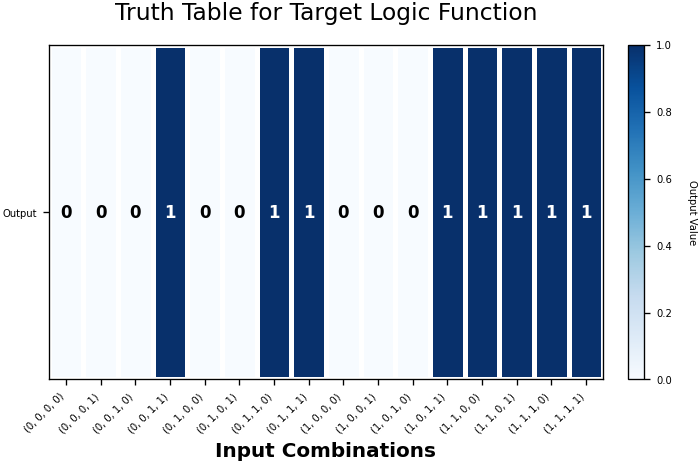

In [ ]:
# Flag to resimulate the IOCRN dynamics of the halls of fame
resimulate_flag = False 

# Flag to load generated IOCRNs from trained models
generated_flag = True

# Flag for filtering out repeated IOCRN topologies
filter_flag = True
num_reactions_template = 4

# Parallel simulation flag
parallel_flag = True

# Set number of inputs and species labels
p = 3                                                   # Number of inputs
mak_order = 2                                           # Maximum order of the mass-action reactions

productions = []
dilutions = []
n_inputs = 4
species_labels = [f'X_{i+1}' for i in range(n_inputs)] 

species_labels.append('OUT') # add output species label

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'Number of CPUs available: {os.cpu_count()}') 

# %%
from RL4CRN.utils.visualizations import plot_truth_table

# Hyperparameters
max_added_reactions = 5                             # Maximum number of reactions
N_CPUs = os.cpu_count()                             # Number of CPUs          
N = 10*N_CPUs                                       # Number of samples (batch size)    
width = 1024                                        # Width of the neural networks  
depth = 5                                           # Depth of the neural networks 
deep_layer_size = 1024*10                           # Size of the deep layer encoding the CRNs
allow_input_influence = False                       # Allow input influence in the policy
learning_rate = 1e-4                                # Learning rate for the optimizer 
hall_of_fame_size = 30                              # Size of the hall of fame  
entropy_scheduler = {                               # Entropy scheduler parameters 
    'entropy_weight': 1e-3, 
    'topk_entropy_weight' : 1.0,
    'remainder_entropy_weight' : 1.0,
    'entropy_update_coefficient': 1, 
    'entropy_schedule': 1000, 
    'minimum_entropy_weight': 0.0
}
entropy_weights_per_head = {'structure': 2.0, 'continuous': 1.0, 'discrete': 0.0, 'input_influence': 0.0} 
structure_head_temperature = {"target_entropy_ratio_to_max": np.log(5)/np.log(5), "initial_temperature": 1.0, "rate": 0.0, "current_temperature": 1.0}
risk_scheduler = {                                  # Risk scheduler parameters
    'risk': 0.95, 
    'risk_update': 0.0, 
    'max_risk': 1.0, 
    'risk_schedule': 1000
}
epoch_num = 300                                     # Number of epochs for training
render_schedule = 10                                 # Render every # of epochs
render_mode = {                                     # Mode of the experiment
    'style': 'logger', 
    'task': 'transients + logic', 
    'format': 'image',
    'topology': True,
    'bounds': [2.5]
}
# Ordering specific parameters
ordering_parameters = {
    'enforce_ordering': False,
    'constraint_weight' : float('inf')
}

render_n_best = 10                                                    # Number of best CRNs to plot responses for
render_disregard_percentage = 0.99                                    # Percentage of worst CRNs to disregard in the responses plotting

# Parameter distribution for the reactions added by the agent
continuous_distribution = {"type": 'lognormal_1D'}

# Time horizon for the simulation
t_f = 100                                           # Final time for the simulation
N_t = 1000                                          # Number of time steps
time_horizon = np.linspace(0, t_f, N_t, dtype=np.float32)

# Construct the IOCRN inputs
# all combination of inputs between 0 and 1 
nums = [0., 1.]
u_list = [np.array(u) for u in product(*[nums for _ in range(n_inputs)])] # list of input combinations, each input is a numpy array of shape (p,)

# --- define the logic function ---
logic_target = lambda u : (u[0] and u[1]) or (u[1] and u[2])  or (u[2] and u[3])

# Construct the reference setpoints
r_list = [np.array([float(logic_target(u))]) for u in u_list]  # list of reference outputs, each output is a numpy array of shape (q,)

# Plot the truth table for the target logic function
plot_truth_table(u_list, r_list, title='Truth Table for Target Logic Function')

# Construct the IOCRN initial conditions
ic = IC(names=species_labels, values=[[0.0 for _ in species_labels]])

# Construct the weights for the performance metric
# w = np.ones(N_t)
# w[(len(w)//5)*4:] = w[(len(w)//5)*4:]*2
# w[:(len(w)//5)] = w[:(len(w)//5)]*0.25
# w = w[np.newaxis, :]
# No transients
w = np.zeros((1, N_t))
w[:, -1] = 1.0 * N_t

# Construct the compute reward routine
def compute_reward(state):
    x0_list = ic.get_ic(state)
    return dynamic_tracking_error(state, u_list, x0_list, time_horizon, r_list, w, norm=1, LARGE_NUMBER=1e4)


In [37]:
# Collect IOCRNs from halls of fame and those generated by trained models
# Get list of hall of fame files
hof_files = [f for f in os.listdir(base_path_hof) if f.startswith('hall_of_fame_') and f.endswith('.pth')]
print(f"Found {len(hof_files)} hall of fame files:")
for file in hof_files:
    print(f"- {file}")
print("-" * 40)

# Get list of generated files
generated_files = [f for f in os.listdir(base_path_models) if f.startswith('generated') and f.endswith('.pth')]
print(f"Found {len(generated_files)} generated files:")
for file in generated_files:
    print(f"- {file}")
print("-" * 40)

# Load the list of IOCRNs from each hall of fame file
hof_data = {}
for file in hof_files:
    file_path = os.path.join(base_path_hof, file)
    hof_data[file] = torch.load(file_path, weights_only=False)
    print(f"Loaded {file} with {len(hof_data[file])} entries.")

# Collect all IOCRNs from the halls of fame into a single list
hof_iocrns = []
for file, iocrn_list in hof_data.items():
    hof_iocrns.extend(iocrn_list)
print("-" * 40)
print(f"Total IOCRNs collected from all halls of fame: {len(hof_iocrns)}")
print("-" * 40)

if generated_flag:
    # Load the list of generated IOCRNs
    generated_data = {}
    for file in generated_files:
        file_path = os.path.join(base_path_models, file)
        generated_data[file] = torch.load(file_path, weights_only=False)
        print(f"Loaded {file} with {len(generated_data[file])} entries.")

    # Collect all IOCRNs from the generated files into a single list
    generated_iocrns = []
    for file, iocrn_list in generated_data.items():
        generated_iocrns.extend(iocrn_list)
    print("-" * 40)
    print(f"IOCRNs collected from all generated files: {len(generated_iocrns)}")

# Collect all IOCRNs into a single list
all_iocrns = hof_iocrns.copy()
if generated_flag:
    all_iocrns.extend(generated_iocrns)
print("-" * 40)
print(f"Total IOCRNs: {len(all_iocrns)}")

Found 1 hall of fame files:
- hall_of_fame_2025-12-08 10:06:10.pth
----------------------------------------
Found 1 generated files:
- generated_2025-12-08 10:06:10.pth
----------------------------------------


Loaded hall_of_fame_2025-12-08 10:06:10.pth with 30 entries.
----------------------------------------
Total IOCRNs collected from all halls of fame: 30
----------------------------------------
Loaded generated_2025-12-08 10:06:10.pth with 1280 entries.
----------------------------------------
IOCRNs collected from all generated files: 1280
----------------------------------------
Total IOCRNs: 1310


In [38]:
# Resimulate the dynamics of each IOCRN if the flag is set
if resimulate_flag:
    print("Resimulating IOCRN dynamics...")

    # Reset all IOCRNs
    for iocrn in all_iocrns:
        iocrn.reset()

    # Simulate each IOCRN
    if parallel_flag:
        results = Parallel(n_jobs=N_CPUs)(delayed(compute_reward)(iocrn) for iocrn in all_iocrns) 
    else:
        results = []
        for iocrn in all_iocrns:
            results.append(compute_reward(iocrn))

    # Unzip the results
    rewards_list, last_task_info_list = zip(*results)
    rewards_list = list(rewards_list)
    last_task_info_list = list(last_task_info_list)

    # Update the last task info in each IOCRN since running in parallel does not modify the IOCRNs themselves
    for i, iocrn in enumerate(all_iocrns):
        iocrn.last_task_info = last_task_info_list[i]            

Filtering topologically unique IOCRNs...
Number of topologically unique IOCRNs: 528 out of 1310 total IOCRNs.


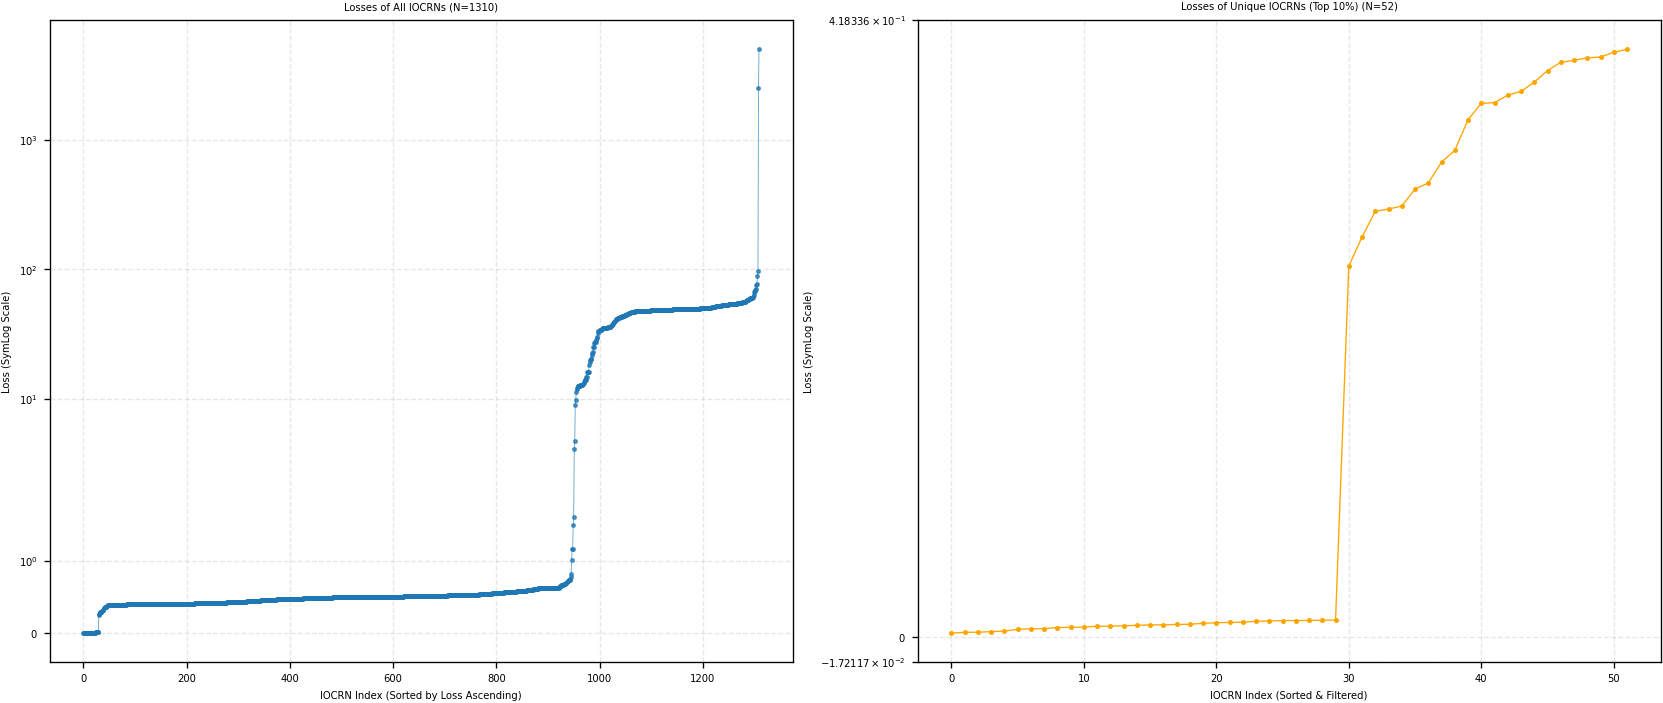

In [39]:
import matplotlib.pyplot as plt
import numpy as np

def plot_unique_rewards(all_iocrns, filter_flag=True, top_percentile=100, figsize=(14, 6)):
    """
    Sorts IOCRNs by reward (loss), optionally filters for topological uniqueness, 
    and plots the reward distribution.

    Args:
        all_iocrns (list): List of IOCRN objects. Each must have .last_task_info['reward'] 
                           and .is_topologically_equal().
        filter_flag (bool): If True, removes topologically duplicate CRNs, keeping the 
                            best-performing version of each topology.
        top_percentile (float): If < 100, restricts the "Unique" plot to the top X% 
                                of topologies. (e.g., 10 = top 10%).
        figsize (tuple): Figure size for the plot.
    """
    
    # 1. Sort all IOCRNs by reward/loss.
    # User Request: "Plotting a loss" -> "Lower values on the left".
    # This implies Ascending Order (Smallest/Best -> Largest/Worst).
    all_iocrns_sorted = sorted(all_iocrns, key=lambda iocrn: iocrn.last_task_info['reward'], reverse=False)

    # 2. Filter topologically unique IOCRNs
    if filter_flag:
        print("Filtering topologically unique IOCRNs...")
        all_iocrns_sorted_filtered = []
        
        if all_iocrns_sorted:
            # The list is sorted [Best, ..., Worst].
            # To keep the BEST version of each topology, we iterate FORWARD.
            # The first time we see a topology, it is the best one (lowest index in sorted list).
            unique_indices = []
            seen_topologies = []
            
            for i in range(len(all_iocrns_sorted)):
                candidate = all_iocrns_sorted[i]
                is_new = True
                for seen in seen_topologies:
                    if candidate.is_topologically_equal(seen):
                        is_new = False
                        break
                
                if is_new:
                    seen_topologies.append(candidate)
                    unique_indices.append(i)
            
            all_iocrns_sorted_filtered = [all_iocrns_sorted[i] for i in unique_indices]
            
        print(f"Number of topologically unique IOCRNs: {len(all_iocrns_sorted_filtered)} out of {len(all_iocrns_sorted)} total IOCRNs.")

    else:
        all_iocrns_sorted_filtered = all_iocrns_sorted

    # 3. Apply Percentile Cutoff (to the Filtered list)
    if top_percentile < 100:
        n_total = len(all_iocrns_sorted_filtered)
        n_keep = max(1, int(n_total * (top_percentile / 100.0)))
        
        # Keep the FIRST n_keep items (Lowest Loss / Best Performance)
        all_iocrns_sorted_filtered = all_iocrns_sorted_filtered[:n_keep]
        title_suffix = f" (Top {top_percentile}%)"
    else:
        title_suffix = ""

    # 4. Extract Rewards
    rewards_sorted = [iocrn.last_task_info['reward'] for iocrn in all_iocrns_sorted]
    rewards_sorted_filtered = [iocrn.last_task_info['reward'] for iocrn in all_iocrns_sorted_filtered]

    # 5. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Left Plot: All IOCRNs
    ax1.plot(rewards_sorted, marker='o', markersize=2, linestyle='-', linewidth=0.5, alpha=0.7)
    ax1.set_yscale('symlog') # symlog handles negative rewards better than log
    ax1.set_xlabel('IOCRN Index (Sorted by Loss Ascending)')
    ax1.set_ylabel('Loss (SymLog Scale)')
    ax1.set_title(f'Losses of All IOCRNs (N={len(rewards_sorted)})')
    ax1.grid(True, which="both", ls="--", alpha=0.3)

    # Right Plot: Unique / Top Percentile
    ax2.plot(rewards_sorted_filtered, marker='o', color='orange', markersize=2, linestyle='-', linewidth=0.8)
    ax2.set_yscale('symlog') # Kept as symlog
    ax2.set_xlabel('IOCRN Index (Sorted & Filtered)')
    ax2.set_ylabel('Loss (SymLog Scale)')
    ax2.set_title(f'Losses of Unique IOCRNs{title_suffix} (N={len(rewards_sorted_filtered)})')
    ax2.grid(True, which="both", ls="--", alpha=0.3)
    
    # Ensure tick labels are visible on Y axis
    ax2.yaxis.set_minor_formatter(plt.ScalarFormatter())

    plt.tight_layout()
    plt.show()

    return all_iocrns_sorted, all_iocrns_sorted_filtered

# Plot the rewards with filtering and top percentile options
all_iocrns_sorted, all_iocrns_sorted_filtered = plot_unique_rewards(all_iocrns, filter_flag=filter_flag, top_percentile=10, figsize=(14, 6))

In [40]:
# Select the top IOCRNs and top topologically unique IOCRNs to visualize
n_unfiltered = 400
n_filtered = 29

sorting...
done ... 


Unfiltered: IOCRN # 400 has a reward of 0.4790758176984894


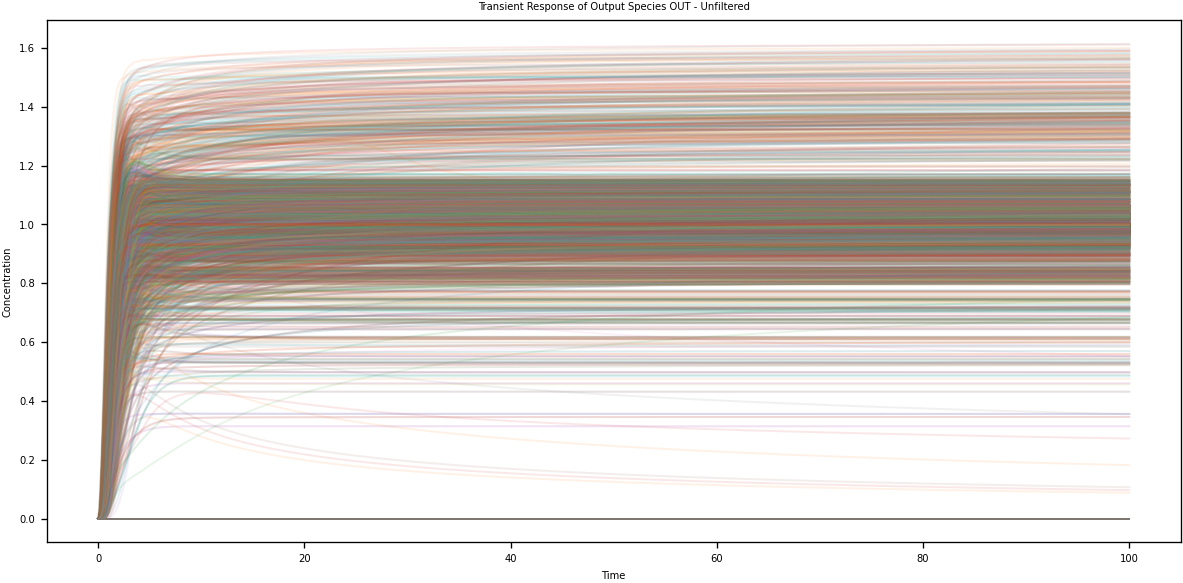

In [41]:
# Plot the responses of the top IOCRNs (topologically not unique)
ax = None
print("sorting...")
all_iocrns_sorted = sorted(all_iocrns, key=lambda iocrn: iocrn.last_task_info['reward'], reverse=False)
print("done ... ")
for i in range(n_unfiltered):
    x0_list = ic.get_ic(all_iocrns_sorted[i])
    fig, ax = all_iocrns_sorted[i].plot_transient_response(axes=ax, alpha=0.1)
ax[0].set_title(ax[0].get_title() + ' - Unfiltered')
print(f'Unfiltered: IOCRN # {n_unfiltered} has a reward of {all_iocrns_sorted[n_unfiltered-1].last_task_info["reward"]}')

In [42]:
len(all_iocrns[0].last_task_info['outputs'])

16

Preparing top 100 trajectories (checking cache first)...
Rendering ensemble...


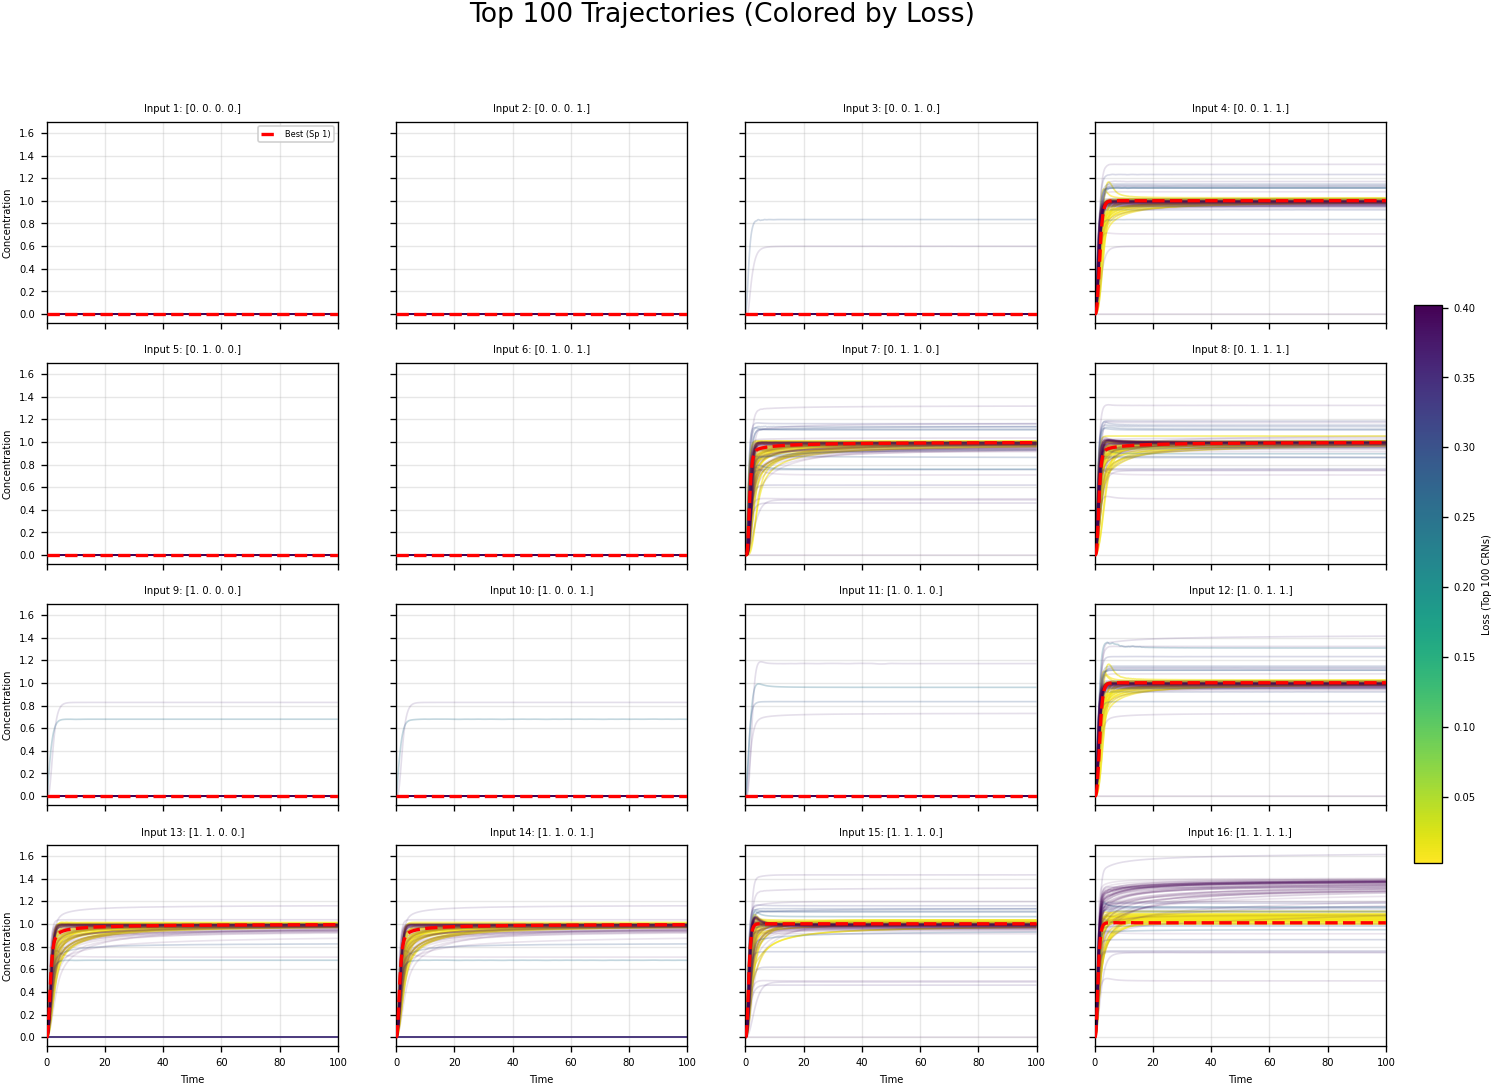

In [43]:


from RL4CRN.utils.visualizations import plot_trajectory_ensemble

# Plot the trajectory ensemble for the top 100 IOCRNs
plot_trajectory_ensemble(
    all_iocrns, 
    ic, 
    u_list, 
    time_horizon, 
    n_top=100,      
    figsize=(15, 10),
    cmap_name="viridis_r", # Reversed: Low Loss (Best) = Yellow/Bright, High Loss = Purple/Dark
    alpha_min=0.1,
    alpha_max=0.6,
    highlight_best=True
)

Filtered: IOCRN # 0 has a reward of 0.0025858822809145324


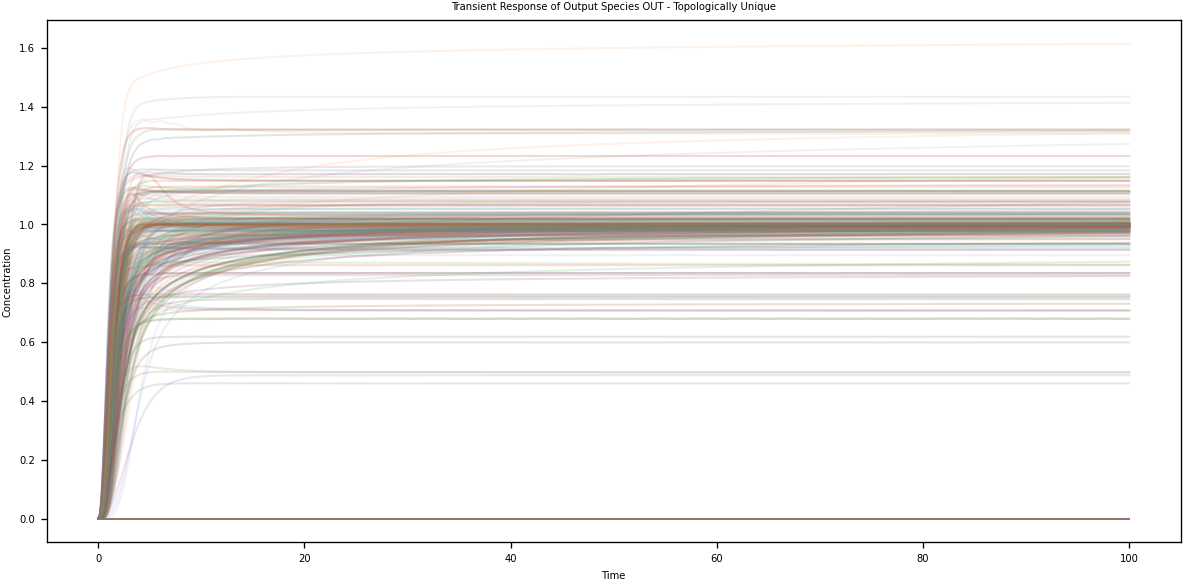

In [44]:
# Plot the responses of the top topologically unique IOCRNs
ax = None
for i in range(len(all_iocrns_sorted_filtered)):
    x0_list = ic.get_ic(all_iocrns_sorted_filtered[i])
    fig, ax = all_iocrns_sorted_filtered[i].plot_transient_response(axes=ax)
ax[0].set_title(ax[0].get_title() + ' - Topologically Unique')
print(f'Filtered: IOCRN # {0} has a reward of {all_iocrns_sorted_filtered[0].last_task_info["reward"]}')

Preparing top 52 trajectories (checking cache first)...
Rendering ensemble...


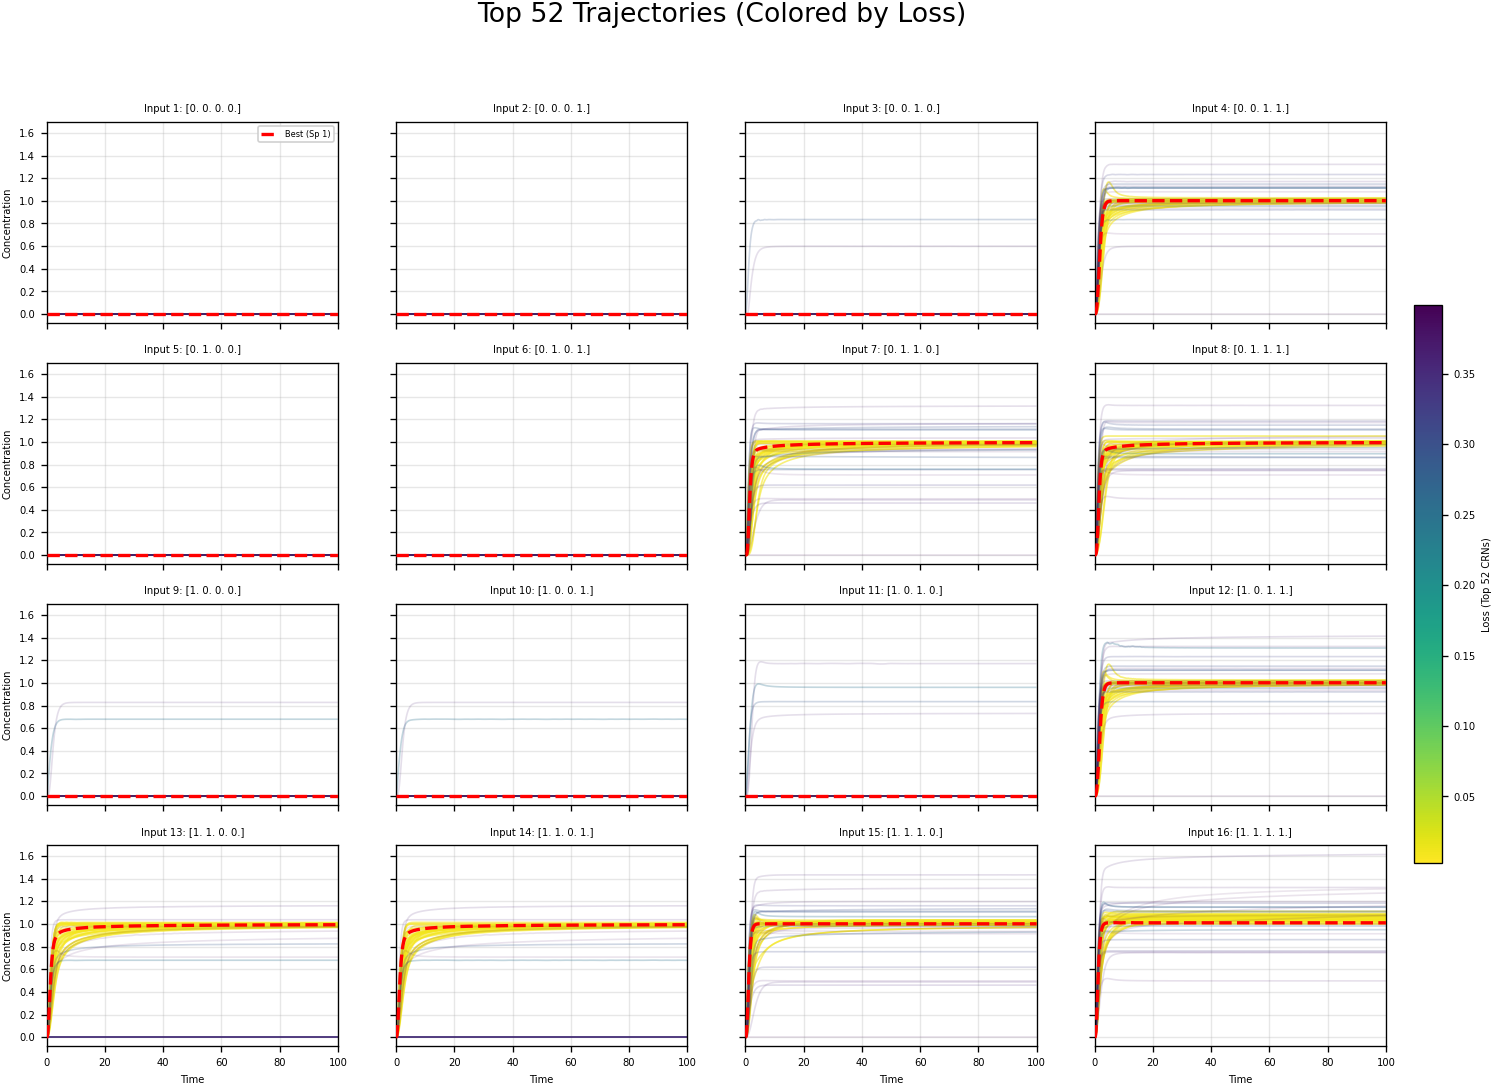

In [45]:
from RL4CRN.utils.visualizations import plot_trajectory_ensemble

# Plot the trajectory ensemble for the top 100 IOCRNs
plot_trajectory_ensemble(
    all_iocrns_sorted_filtered, 
    ic, 
    u_list, 
    time_horizon, 
    n_top=100,      
    figsize=(15, 10),
    cmap_name="viridis_r", # Reversed: Low Loss (Best) = Yellow/Bright, High Loss = Purple/Dark
    alpha_min=0.1,
    alpha_max=0.6,
    highlight_best=True
)

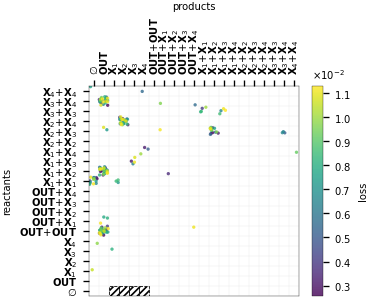

In [46]:
# Plot the reactant-product scatter for the top unfiltered IOCRNs
rewards_sorted = [iocrn.last_task_info['reward'] for iocrn in all_iocrns_sorted]

# sort species labels to match the number of species in the IOCRNs
species_labels = ['OUT'] + [f'X_{i+1}' for i in range(n_inputs)]
num_reactions_template = 4

# Reactant-Product Scatter Plot
plot_dic = {
        "font.size": 6,
        "axes.labelsize": 6,
        "axes.titlesize": 6,
        "legend.fontsize": 6,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "axes.linewidth": 0.2,
        "lines.linewidth": 1.2,
        "figure.dpi": 120,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    }

fig = plot_reactant_product_scatter(
    all_iocrns_sorted_filtered[0:n_filtered],
    perf=rewards_sorted[0:n_filtered],
    species_labels=species_labels,
    max_order= mak_order,
    num_reactions_template=num_reactions_template,
    title="",
    cmap_name="viridis",
    max_ticks=30,
    figsize=(2*1.6, 1.65*1.6),
    jitter_scale=0.45,
    use_plotly=False,
    plot_dic=plot_dic,
    marker_size=4
)

fig.savefig(os.path.join(target_directory, 'plots', "rpa_ssa_reactant_product_scatter.pdf"))

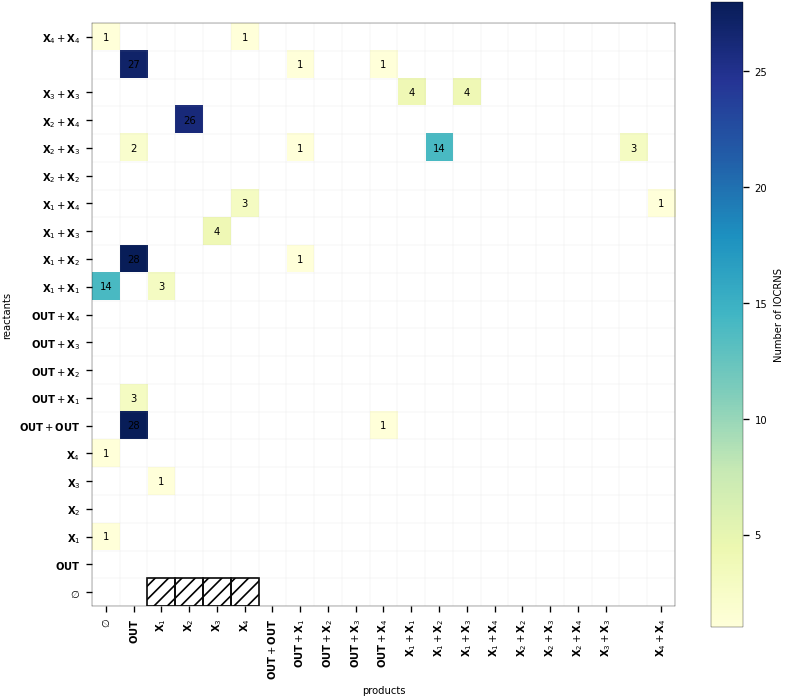

In [47]:
# Plot the reactant-product heatmap for the top filtered IOCRNs (topologically unique)
plot_reactant_product_heatmap(
    all_iocrns_sorted_filtered[0:n_filtered],
    species_labels,
    max_order= mak_order,
    num_reactions_template=num_reactions_template,
    title="",
    cmap_name="YlGnBu",
    max_ticks=20,
    figsize=(7, 6),
)

Applied reward weighting (alpha=10.0). Edges stretched by fitness gaps.
Computing layout (mds)...
Dual Coloring: Face=Loss (Greyscale), Edge=Cluster (Rainbow) with Black Separator


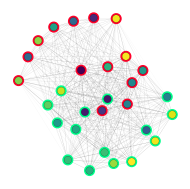

In [48]:
from RL4CRN.utils.visualizations import visualize_crn_diversity
rewards_sorted_filtered = [iocrn.last_task_info.get('reward') for iocrn in all_iocrns_sorted_filtered]
# use unique filtered iocrns

# Topological diversity graph
plot_dic = {
        "font.size": 6,
        "axes.labelsize": 6,
        "axes.titlesize": 6,
        "legend.fontsize": 6,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.2,
        "figure.dpi": 120,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    }

graph_dic = {
        "fontsize": 3,                  # font size for node labels 
        "edgewidth": 0.1,               # width of the edges in the graph
        "nodesize_multiplier":10,       # multiplier for node sizes
        "nodesize_offset": 0,           # offset for node sizes
        "show_colorbar": False,         # whether to show colorbar for node colors
        "innersize_ratio": 3,           # ratio for inner size of nodes
        "inner_node_linewidth": 0.1,    # width of the inner node borders 
        "outer_node_linewidth": 4.0,     # width of the outer node borders
        "print_labels": False               # whether to print labels on the nodes
    }

fig = visualize_crn_diversity(
    all_iocrns_sorted_filtered[:n_filtered], 
    perf=rewards_sorted_filtered[:n_filtered], 
    k=None, 
    t=12, 
    layout_method="mds", 
    label_percentile=50, 
    alpha=10.0, 
    unique=True, 
    plot_dic=plot_dic,
    graph_dic=graph_dic,
    figsize=(2, 2)
)
fig.savefig("RPA_unique_topology_reward_weighted.pdf", format='pdf')

In [49]:
print(all_iocrns_sorted_filtered[0])


Inputs: ['u_1', 'u_2', 'u_3', 'u_4'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3', 'X_4'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
∅ ----> X_4;  [MAK(1.0, u_4)]
X_1 + X_1 ----> ∅;  [MAK(1.1645601987838745)]
X_1 + X_2 ----> OUT;  [MAK(2.6063761711120605)]
X_2 + X_3 ----> X_1 + X_2;  [MAK(3.1051557064056396)]
X_2 + X_4 ----> X_2;  [MAK(31.008514404296875)]
X_3 + X_4 ----> OUT;  [MAK(0.6210935115814209)]
OUT + OUT ----> OUT;  [MAK(0.9974201917648315)]


In [50]:
print(all_iocrns_sorted_filtered[1])


Inputs: ['u_1', 'u_2', 'u_3', 'u_4'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3', 'X_4'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
∅ ----> X_4;  [MAK(1.0, u_4)]
X_1 + X_2 ----> OUT;  [MAK(0.8410307168960571)]
X_1 + X_3 ----> X_3;  [MAK(10.044052124023438)]
X_2 + X_3 ----> X_1 + X_2;  [MAK(10.07668685913086)]
X_2 + X_4 ----> X_2;  [MAK(5.864566326141357)]
X_3 + X_4 ----> OUT;  [MAK(3.2204887866973877)]
OUT + OUT ----> OUT;  [MAK(1.0014324188232422)]


In [51]:
print(all_iocrns_sorted_filtered[3])

Inputs: ['u_1', 'u_2', 'u_3', 'u_4'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3', 'X_4'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
∅ ----> X_4;  [MAK(1.0, u_4)]
X_1 + X_1 ----> ∅;  [MAK(7.688343524932861)]
X_1 + X_2 ----> OUT + X_1;  [MAK(0.8636011481285095)]
X_2 + X_3 ----> X_1 + X_2;  [MAK(0.8966131806373596)]
X_2 + X_4 ----> X_2;  [MAK(12.732108116149902)]
X_3 + X_4 ----> OUT;  [MAK(1.5404425859451294)]
OUT + OUT ----> OUT;  [MAK(1.0168092250823975)]


Filtered: IOCRN # 0 has a reward of 0.0025858822809145324
Filtered: IOCRN # 28 has a reward of 0.011296859393140483


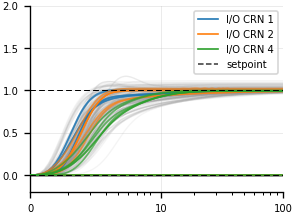

In [68]:
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
save_figures_flag = True

iocrn_indices_to_highlight = [0, 1, 3]  # Indices of IOCRNs to highlight in the plot
# Transient dynamics plot
plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "legend.fontsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

fig, ax = plt.subplots(figsize=(2.5, 1.85), constrained_layout=True) 

# --------- Plot all traces in light gray (topologically unique) ----------
alpha_bg = 0.1     # transparency for background traces
lw_bg = 0.8         # line width for background traces
time_shift = 1      # shift time to avoid log(0)

for i in range(n_filtered):
    info = all_iocrns_sorted_filtered[i].last_task_info
    t = info["time_horizon"] + time_shift
    outs = info["outputs"]

    for j in range(len(outs)):
        ax.plot(t, outs[j][0, :],
                color="0.6", alpha=alpha_bg, linewidth=lw_bg, zorder=1)

print(f'Filtered: IOCRN # {0} has a reward of {all_iocrns_sorted_filtered[0].last_task_info["reward"]}')
print(f'Filtered: IOCRN # {n_filtered-1} has a reward of {all_iocrns_sorted_filtered[n_filtered-1].last_task_info["reward"]}')

# --------- Highlight the selected IOCRNs ----------
lw_hi = 1

for i in range(len(iocrn_indices_to_highlight)):
    info = all_iocrns_sorted_filtered[iocrn_indices_to_highlight[i]].last_task_info
    t = info["time_horizon"] + time_shift
    outs = info["outputs"]

    color = f"C{i}"  # Matplotlib standard cycle
    label = f"I/O CRN {i+1}"

    for j in range(len(outs)):
        ax.plot(
            t, outs[j][0, :],
            alpha=u_list[j][1] / 1.5,          # keep your per-trace alpha
            color=color, linewidth=lw_hi,
            zorder=3,
            label=label if j == 0 else None   # label once per i
        )

# --------- Axes cosmetics ----------
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --------- Scales/limits (set before setpoint lines so we know xmin/xmax) ----------
ax.set_xscale("log")
ax.set_ylim(0, 2.5)
ax.set_xlim(time_shift, t_f + time_shift)

# 1) dashed setpoint lines from u_list[*][1]
xmin, xmax = ax.get_xlim()
for j in range(len(u_list)):
    sp = u_list[j][1]  # "entry one" (index 1)
    ax.hlines(
        y=sp, xmin=xmin, xmax=xmax,
        colors="k",
        linewidth=0.3,
        linestyle=(0, (10, 8)),  # (dash_length, gap_length) -> larger gap
        zorder=3
    )

# 2) Legend for colored lines should not have alpha:
#    use proxy artists with alpha=1 so legend is fully opaque.
color_handles = [Line2D([0], [0], color=f"C{i}", lw=lw_hi, alpha=1.0) for i in range(len(iocrn_indices_to_highlight))]
color_labels  = [f"I/O CRN {i+1}" for i in iocrn_indices_to_highlight]

# Dashed Line for Setpoint
setpoint_handle = Line2D([0], [0], color="0.2", lw=0.9, ls="--")
handles = color_handles + [setpoint_handle]
labels  = color_labels + ["setpoint"]

ax.set_xticks(np.array([0, 10, 100]) + time_shift)
ax.set_xticklabels(ax.get_xticks() - time_shift, rotation=0)

ax.legend(handles=handles, labels=labels, frameon=True, loc="upper right", handlelength=2)
ax.set_ylim(-0.2, 2.)
plt.show()

if save_figures_flag is True:
    fig.savefig(os.path.join(target_directory, 'plots', "Logic_5pecies_5rxns_transient_dynamics.pdf"))

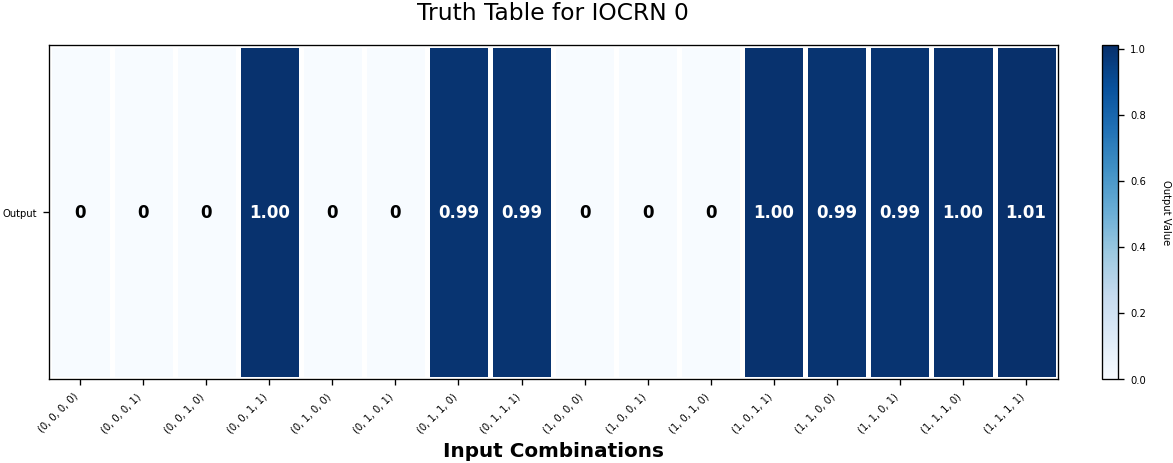

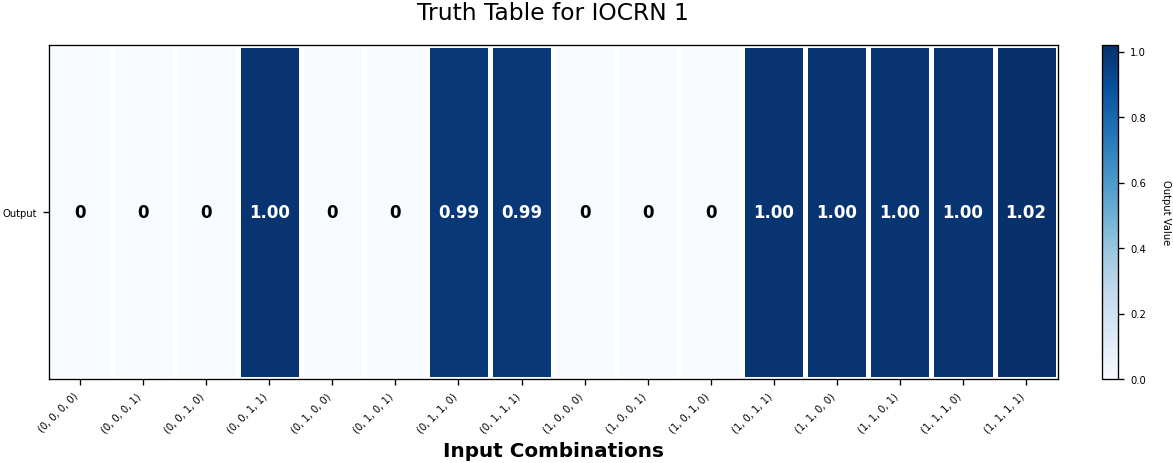

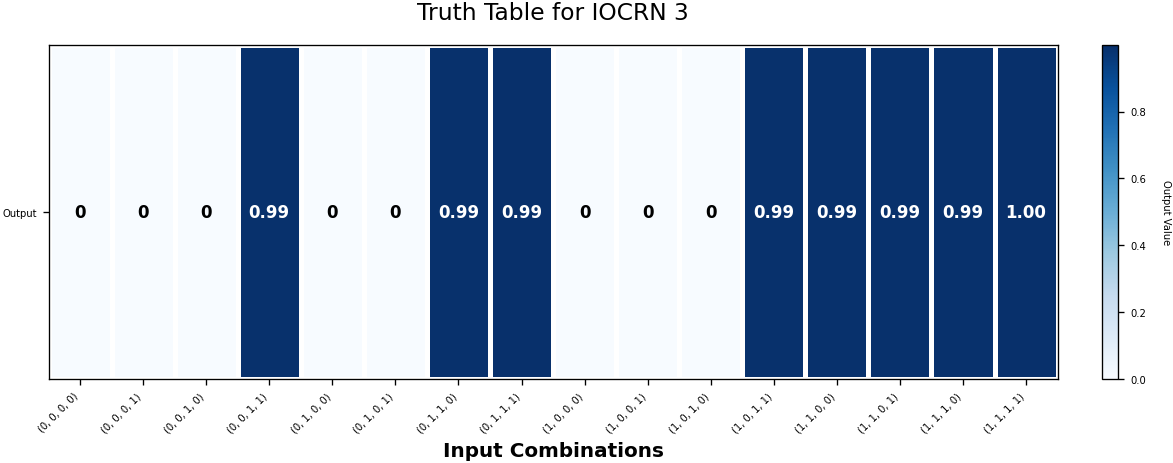

In [52]:
def get_outputs(iocrn):
    return [o[0][-1] for o in iocrn.last_task_info['outputs']]


for i in [0, 1, 3]:
    plot_truth_table(
        u_list,
        get_outputs(all_iocrns_sorted_filtered[i]),
        title=f"Truth Table for IOCRN {i}",
        figsize=(10, 4)
    )

pass

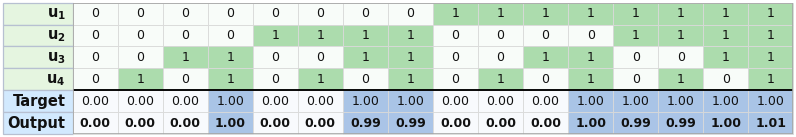

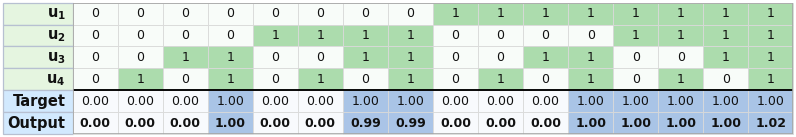

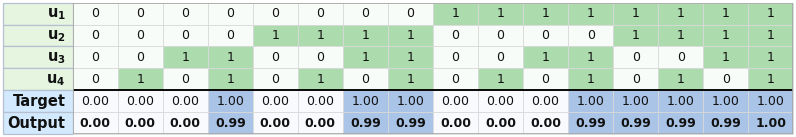

In [67]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import os

def plot_truth_table_transposed_nature(
    u_list,
    actual_outputs,
    logic_function,
    title="Truth table",
    figsize=(2.2, 1.2),
    silent=False,
):
    """
    Nature Methods–style transposed truth table (Refined):
    - Font size 6 for data.
    - First column (labels) colored to match sections (Green/Red).
    - Shading intensity reduced (pastel/lighter).
    """

    rc = {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 6,
        "axes.titlesize": 9,
        "axes.titleweight": "bold",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    }

    def make_gradient_cmap(base_color):
        base_rgb = mcolors.to_rgb(base_color)
        return mcolors.LinearSegmentedColormap.from_list(
            f"grad_{base_color}", ["#FFFFFF", mcolors.to_hex(base_rgb)], N=256
        )

    def to_cell_color(val, cmap, vmin=0.0, vmax=1.0):
        if np.isnan(val):
            return (0.97, 0.97, 0.97, 1.0) # very light grey for NaNs
        t = (val - vmin) / (vmax - vmin + 1e-12)
        t = float(np.clip(t, 0.0, 1.0))
        
        # REDUCED INTENSITY:
        # Map 0.0 -> 0.05 (almost white)
        # Map 1.0 -> 0.60 (pastel, not full saturation)
        t = 0.05 + 0.55 * t 
        return cmap(t)

    def best_text_color(rgba):
        r, g, b = rgba[:3]
        lum = 0.2126 * r + 0.7152 * g + 0.0722 * b
        return "#111111" if lum > 0.6 else "#FFFFFF"

    with mpl.rc_context(rc):
        # ----- Data prep -----
        u_matrix = np.array(u_list, dtype=float)
        if u_matrix.ndim == 1:
            u_matrix = u_matrix.reshape(-1, 1)
        n_samples, n_inputs = u_matrix.shape

        targets = []
        for row in u_matrix:
            try:
                targets.append(float(logic_function(row)))
            except Exception:
                targets.append(np.nan)
        targets = np.array(targets, dtype=float)

        actuals = np.array(actual_outputs, dtype=float).flatten()
        if actuals.size != n_samples:
             actuals = np.resize(actuals, n_samples) 

        # ----- Colormaps (Pastel/Lighter Base) -----
        # Using lighter hex codes for base colors to keep shading gentle
        base_green = "#74c476"  # Pastel Green
        base_red   = "#709cd6"  # Pastel Red
        
        cmap_input = make_gradient_cmap(base_green)
        cmap_output = make_gradient_cmap(base_red)

        # Background colors for the label column (static light shades)
        # We pick a very light version of the base colors for the labels
        label_bg_input = mcolors.to_rgba("#e5f5e0") # Very pale green
        label_bg_output = mcolors.to_rgba("#d2e9fe") # Very pale red

        # ----- Build table data -----
        row_labels = [f"$\\bf{{u_{{{i+1}}}}}$" for i in range(n_inputs)] + ["Target", "Output"]
        cell_text, cell_colors = [], []

        # 1. Inputs
        for i in range(n_inputs):
            vals = u_matrix[:, i]
            cell_text.append([f"{x:g}" for x in vals])
            cell_colors.append([to_cell_color(x, cmap_input) for x in vals])

        # 2. Target
        cell_text.append([("—" if np.isnan(t) else f"{t:.2f}") for t in targets])
        cell_colors.append([to_cell_color(t, cmap_output) for t in targets])

        # 3. Output
        cell_text.append([f"{a:.2f}" for a in actuals])
        cell_colors.append([to_cell_color(a, cmap_output) for a in actuals])

        # ----- Figure -----
        fig, ax = plt.subplots(figsize=figsize)
        ax.axis("off")

        top_margin = 0.16
        fig.subplots_adjust(top=1 - top_margin)
        bbox = [0.0, 0.0, 1.0, 1.0]

        tbl = ax.table(
            cellText=cell_text,
            cellColours=cell_colors,
            rowLabels=row_labels,
            cellLoc="center",
            loc="center",
            bbox=bbox,
        )

        tbl.auto_set_font_size(False)
        tbl.set_fontsize(6)

        # ----- Styling -----
        grid_col = "#D9D9D9"
        outer_col = "#A6A6A6"
        label_edge = "#B7C0D1"
        label_text = "#111111"

        idx_target = n_inputs
        idx_output = n_inputs + 1

        for (row, col), cell in tbl.get_celld().items():
            cell.set_edgecolor(grid_col)
            cell.set_linewidth(0.4)

            # --- Row Labels (First Column) ---
            if col == -1:
                # Apply specific shading based on row type
                if row < n_inputs:
                    cell.set_facecolor(label_bg_input)
                else:
                    cell.set_facecolor(label_bg_output)
                
                cell.set_edgecolor(label_edge)
                cell.set_linewidth(0.6)
                cell.set_text_props(color=label_text, weight="bold", ha="right")
                cell.set_fontsize(7) # Slightly larger for labels
            
            # --- Data Cells ---
            else:
                tc = best_text_color(cell.get_facecolor())
                weight = "bold" if row == idx_output else "normal"
                cell.set_text_props(color=tc, weight=weight)
                cell.set_fontsize(6)

        # ----- Separation line (black) -----
        total_rows = len(row_labels)
        row_h = bbox[3] / total_rows
        y_sep = bbox[1] + bbox[3] - (n_inputs * row_h)

        ax.add_line(
            plt.Line2D(
                [bbox[0], bbox[0] + bbox[2]],
                [y_sep, y_sep],
                transform=ax.transAxes,
                color="#000000",
                linewidth=0.9,
                zorder=10,
            )
        )

        # ----- Outer border -----
        ax.add_patch(
            patches.Rectangle(
                (bbox[0], bbox[1]),
                bbox[2],
                bbox[3],
                transform=ax.transAxes,
                fill=False,
                edgecolor=outer_col,
                linewidth=0.8,
                zorder=10,
            )
        )

        if not silent:
            plt.show()

        return fig, ax
def get_outputs(iocrn):
    return [o[0][-1] for o in iocrn.last_task_info['outputs']]


for i in [0, 1, 3]:
    fig, ax = plot_truth_table_transposed_nature(
        u_list,
        get_outputs(all_iocrns_sorted_filtered[i]),
        logic_target,
        title=f"Truth Table for IOCRN {i}",
        figsize=(6.2, 1.2)
    )
    fig.savefig(os.path.join(target_directory, 'plots', f"truth_table_iocrn_{i}.pdf"))
pass